In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [3]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [4]:
DATA_DIR = r"C:\Users\Mathumitha\Desktop\Mathu\veg"

TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "validation")
TEST_DIR  = os.path.join(DATA_DIR, "test")

In [5]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

In [6]:
class_names = [
'beetroot','cabbage','capsicum','carrot','cauliflower',
'cucumber','eggplant','potato','raddish','tomato'
]

In [7]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=class_names
)

Found 858 files belonging to 10 classes.


In [8]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=class_names
)


Found 98 files belonging to 10 classes.


In [9]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    class_names=class_names
)


Found 100 files belonging to 10 classes.


In [10]:
class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:",class_names)

Classes: ['beetroot', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'cucumber', 'eggplant', 'potato', 'raddish', 'tomato']


In [11]:
data_augmentation = keras.Sequential([
    
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

])

In [12]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

In [13]:
base_model.trainable = False

In [14]:
model = keras.Sequential([

    layers.Input(shape=(224,224,3)),

    data_augmentation,

    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
    
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dense(128,activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(num_classes,activation="softmax")
])

In [15]:
model.compile(

    optimizer=keras.optimizers.Adam(learning_rate=0.0001),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,428,362 (9.26 MB)

 Trainable params: 167,818 (655.54 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [16]:
callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3
    ),

    keras.callbacks.ModelCheckpoint(
        "best_model_mobilenet.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]


In [17]:
history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=25,

    callbacks=callbacks
)

Epoch 1/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.1678 - loss: 2.6574 - val_accuracy: 0.4184 - val_loss: 1.8862 - learning_rate: 1.0000e-04
Epoch 2/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.4580 - loss: 1.6906 - val_accuracy: 0.6735 - val_loss: 1.3172 - learning_rate: 1.0000e-04
Epoch 3/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.6154 - loss: 1.1634 - val_accuracy: 0.7755 - val_loss: 0.9504 - learning_rate: 1.0000e-04
Epoch 4/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.7331 - loss: 0.8993 - val_accuracy: 0.8776 - val_loss: 0.7148 - learning_rate: 1.0000e-04
Epoch 5/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.7797 - loss: 0.6946 - val_accuracy: 0.9082 - val_loss: 0.5686 - learning_rate: 1.0000e-04
Epoch 6/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.8205 - loss: 0.6046 - val_accuracy: 0.9082 - val_loss: 0.4772 - learning_rate: 1.0000e-04
Epoch 7/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.8403 - loss:

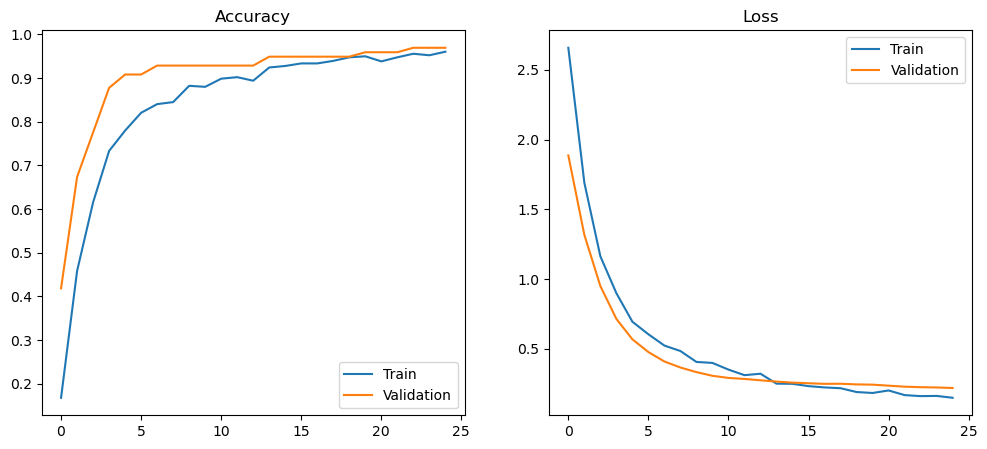

In [18]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")
plt.legend(["Train","Validation"])

plt.show()


In [19]:
test_loss,test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:",test_accuracy*100)

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 722ms/step - accuracy: 0.9700 - loss: 0.2159
Test Accuracy: 97.00000286102295


In [20]:
y_true = np.concatenate([y for x,y in test_ds],axis=0)

y_pred_prob = model.predict(test_ds)

y_pred = np.argmax(y_pred_prob,axis=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step


In [21]:
print(classification_report(y_true,y_pred,target_names=class_names))

              precision    recall  f1-score   support

    beetroot       1.00      1.00      1.00        10
     cabbage       1.00      1.00      1.00        10
    capsicum       1.00      1.00      1.00        10
      carrot       1.00      0.90      0.95        10
 cauliflower       0.91      1.00      0.95        10
    cucumber       1.00      1.00      1.00        10
    eggplant       0.91      1.00      0.95        10
      potato       1.00      0.80      0.89        10
     raddish       0.91      1.00      0.95        10
      tomato       1.00      1.00      1.00        10

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100



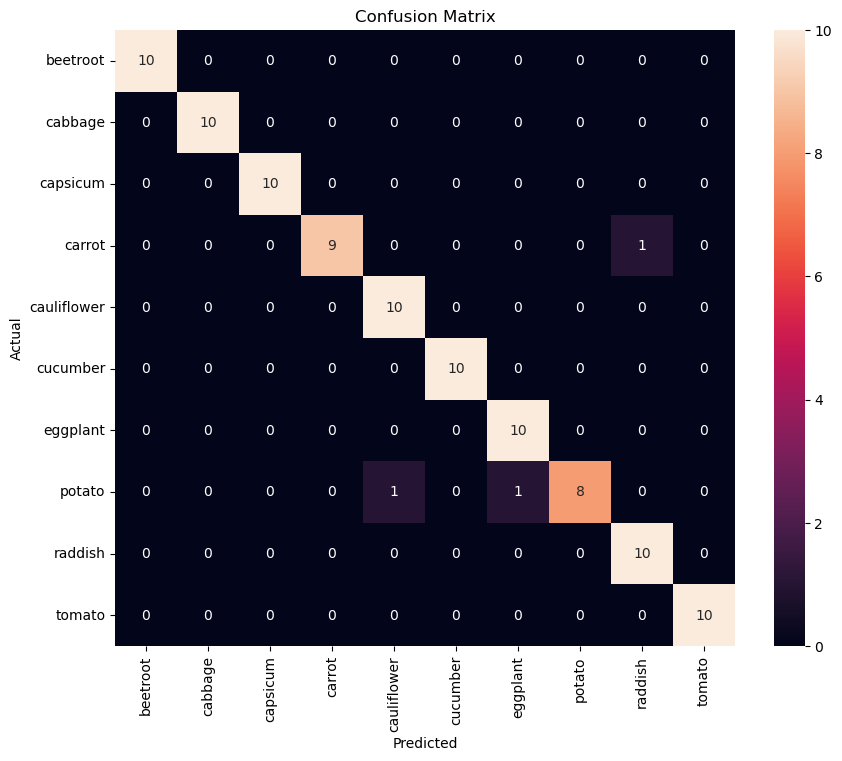

In [22]:
cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


In [23]:
model.save("mobilenet_model.keras")

print("Final model saved")

Final model saved
